## LEM Epoch Comparison

In [ ]:
import time
import psutil
import os
import gc
import threading
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import mne
import sys

sys.path.append("../..")
import act as act_cpu_mod
import act_lem as act_lem_mod
import act_gpu_cuda as act_gpu_mod

In [2]:
class TraceMonitor:
    def __init__(self, interval: float = 0.05):
        self.interval = interval
        self._proc = psutil.Process(os.getpid())
        self._stop_event = threading.Event()
        self._thread = threading.Thread(target=self._run, daemon=True)
        # time-series lists
        self.timestamps: list = []
        self.cpu_mb: list = []
        self.gpu_mb: list = []
        self.combined_mb: list = []
        # phase boundary
        self.t_build_done: float = None
        self._t0: float = None

    def _sample(self):
        cpu = self._proc.memory_info().rss / 1024**2
        gpu = cp.get_default_memory_pool().used_bytes() / 1024**2
        t   = time.perf_counter() - self._t0
        self.timestamps.append(t)
        self.cpu_mb.append(cpu)
        self.gpu_mb.append(gpu)
        self.combined_mb.append(cpu + gpu)

    def _run(self):
        while not self._stop_event.is_set():
            self._sample()
            time.sleep(self.interval)

    def start(self):
        self.timestamps = []
        self.cpu_mb = []
        self.gpu_mb = []
        self.combined_mb = []
        self.t_build_done = None
        self._t0 = time.perf_counter()
        self._stop_event.clear()
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()

    def mark_build_done(self):
        """Call this between build and transform to record the phase boundary."""
        self.t_build_done = time.perf_counter() - self._t0

    def stop(self):
        self._stop_event.set()
        self._thread.join()
        self._sample()  # final sample

    @property
    def peak_cpu_mb(self):
        return max(self.cpu_mb) if self.cpu_mb else 0.0

    @property
    def peak_gpu_mb(self):
        return max(self.gpu_mb) if self.gpu_mb else 0.0

    @property
    def peak_combined_mb(self):
        return max(self.combined_mb) if self.combined_mb else 0.0


def reset_memory():
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()

In [ ]:
EDF_PATH = os.path.join(os.getcwd(), '../Testing Scripts/Data/sub-1_task-Sleep_acq-headband_eeg.edf')
EEG_CHANNELS = ["HB_1"]
FS           = 256
TC_RES       = 2 * FS  # 512 samples

fc_info    = (0.5, 15, 0.5)
logDt_info = (-4,  1,  0.5)
c_info     = (-10, 10, 0.5)
tc_info    = (0, TC_RES, 16)

COMMON_KWARGS = dict(
    FS=FS, length=TC_RES,
    tc_info=tc_info, fc_info=fc_info,
    logDt_info=logDt_info, c_info=c_info,
    mute=True,
)

LEM_KWARGS = dict(
    order=10,
    refine_levels=2,
    top_k=4,
    radius_steps=2,
    coarse_range=[[0, TC_RES], [0.5, 15.0], [-4.0, 1.0], [-10.0, 10.0]],
    step_size=[
        (64, 2.0, 2.0, 5.0),
        (32, 1.0, 1.0, 2.0),
        (16, 0.5, 0.5, 0.5),
    ],
)

In [4]:
raw = mne.io.read_raw_edf(EDF_PATH, preload=True, verbose=False)
raw.pick_channels(EEG_CHANNELS)
raw.notch_filter(freqs=50)
raw.filter(l_freq=0.101, h_freq=20.0, verbose=False) # 0.101 avoids MNE filter-length edge case at exactly 0.1 Hz- for some reason this specific run is affected
data = raw.get_data().T

segment_cpu = data[:TC_RES, 0]
segment_gpu = cp.asarray(segment_cpu)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1691 samples (6.605 s)



In [5]:
results = {}

def run_model(name, build_fn, transform_fn):
    reset_memory()
    mon = TraceMonitor(interval=0.05)

    model = build_fn()
    _ = transform_fn(model)
    cp.cuda.Stream.null.synchronize()  # make sure GPU is done

    reset_memory()
    mon.start()

    t0 = time.perf_counter()
    model = build_fn()
    t_build = time.perf_counter() - t0

    mon.mark_build_done()

    t1 = time.perf_counter()
    out = transform_fn(model)
    t_transform = time.perf_counter() - t1

    mon.stop()

    results[name] = {
        "out":           out,
        "t_build_s":     t_build,
        "t_transform_s": t_transform,
        "runtime_s":     t_build + t_transform,
        "peak_cpu_mb":   mon.peak_cpu_mb,
        "peak_gpu_mb":   mon.peak_gpu_mb,
        "peak_combined_mb": mon.peak_combined_mb,
        "trace":         mon,  # keep the full trace for plotting
    }
    print(f"  {name:6s}  build={t_build:.3f}s  transform={t_transform:.3f}s  "
          f"total={t_build+t_transform:.3f}s  "
          f"peak CPU={mon.peak_cpu_mb:.1f} MB  peak GPU={mon.peak_gpu_mb:.1f} MB  "
          f"peak combined={mon.peak_combined_mb:.1f} MB")

In [6]:
print("\n=== CPU ACT ===")
run_model(
    "CPU",
    build_fn=lambda: act_cpu_mod.ACT(**COMMON_KWARGS, force_regenerate=True),
    transform_fn=lambda m: m.transform(segment_cpu, order=10),
)

print("\n=== GPU LEM ACT ===")
run_model(
    "LEM",
    build_fn=lambda: act_lem_mod.ACT_LEM(**COMMON_KWARGS),
    transform_fn=lambda m: m.transform(segment_gpu, **LEM_KWARGS),
)

print("\n=== GPU ACT ===")
run_model(
    "GPU",
    build_fn=lambda: act_gpu_mod.ACT(**COMMON_KWARGS, force_regenerate=True),
    transform_fn=lambda m: m.transform(segment_gpu, order=10),
)


=== CPU ACT ===
Dictionary length: 371200
Dictionary length: 371200
  CPU     build=6.872s  transform=1.969s  total=8.841s  peak CPU=2767.6 MB  peak GPU=0.0 MB  peak combined=2767.6 MB

=== GPU LEM ACT ===
Level 0 coarse candidates (top 4): [array([412.4274   ,   2.9323564,  -0.8489298,   4.2107296], dtype=float32), array([453.65045   ,   0.84820426,  -2.4003372 ,   4.9359083 ],
      dtype=float32), array([442.85938  ,   1.1431756,  -1.9650488,  -7.7489047], dtype=float32), array([242.74048  ,   3.9844825,  -1.2802948,  -7.696721 ], dtype=float32)]

Level 0 coarse candidates (top 4): [array([118.834885 ,   2.0469291,  -2.6423123,   4.278689 ], dtype=float32), array([134.15967  ,   0.6268988,  -1.2284347,  -3.5759628], dtype=float32), array([117.71301  ,   2.6196296,  -2.6666145,  -9.610043 ], dtype=float32), array([132.1242   ,   2.168643 ,  -2.9531684,  -2.3190486], dtype=float32)]

Level 0 coarse candidates (top 4): [array([120.584465 ,   1.3297014,  -2.3236892,   1.5357491], dtype

In [7]:
def to_numpy(x):
    return cp.asnumpy(x) if isinstance(x, cp.ndarray) else np.asarray(x)

for name, r in results.items():
    r["approx"]   = to_numpy(r["out"]["approx"])
    r["residue"]  = to_numpy(r["out"]["residue"])
    r["norm_res"] = np.linalg.norm(r["residue"]) / np.linalg.norm(segment_cpu)


# PRINT SUMMARY TABLE
# ─────────────────────────────────────────────

print("\n" + "=" * 95)
print(f"{'Model':<6} {'Build (s)':>10} {'Transform (s)':>14} {'Total (s)':>10} "
      f"{'Norm Res':>10} {'Peak CPU MB':>12} {'Peak GPU MB':>12} {'Peak Total MB':>14}")
print("-" * 95)
for name, r in results.items():
    print(f"{name:<6} {r['t_build_s']:>10.3f} {r['t_transform_s']:>14.3f} "
          f"{r['runtime_s']:>10.3f} {r['norm_res']:>10.6f} "
          f"{r['peak_cpu_mb']:>12.1f} {r['peak_gpu_mb']:>12.1f} "
          f"{r['peak_combined_mb']:>14.1f}")
print("=" * 95)


Model   Build (s)  Transform (s)  Total (s)   Norm Res  Peak CPU MB  Peak GPU MB  Peak Total MB
-----------------------------------------------------------------------------------------------
CPU         6.872          1.969      8.841   0.052766       2767.6          0.0         2767.6
LEM         0.000         10.348     10.348   0.073194        819.1         17.2          835.1
GPU         7.515          1.535      9.050   0.052766       2581.9       1461.3         4043.2


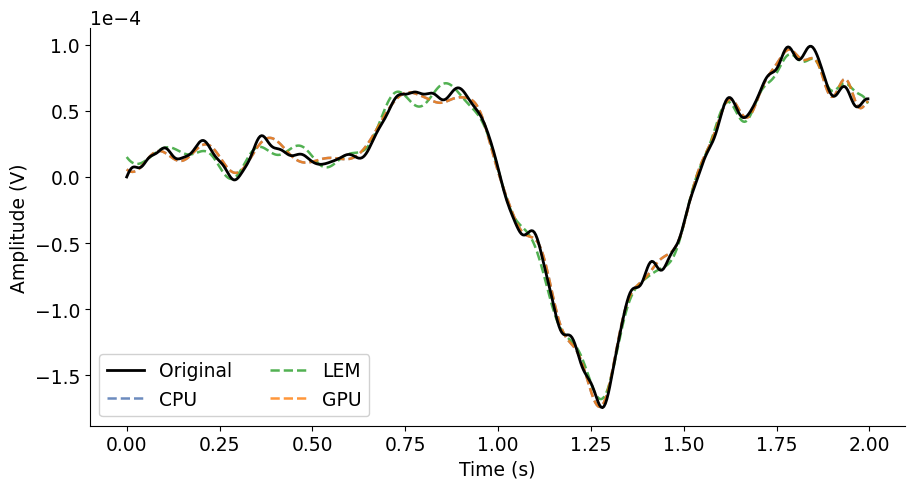

In [8]:
fig, ax = plt.subplots(figsize=(9.25, 5), facecolor="white")
ax.set_facecolor("white")
COLORS = {"CPU": "#4C72B0", "GPU": "#ff7f0e", "LEM": "#2ca02c"}

t = np.arange(TC_RES) / FS

ax.plot(t, segment_cpu, color="black", linewidth=2.0,
        label="Original", zorder=10)

for name, r in results.items():
    approx = r["approx"]
    if approx.ndim == 2:
        approx = approx[0]
    ax.plot(t, approx, color=COLORS[name], linewidth=1.8,
            alpha=0.82, linestyle="--", label=f"{name}", zorder=5)

ax.set_xlabel("Time (s)", fontsize=13.5)
ax.set_ylabel("Amplitude (V)", fontsize=13.5)
ax.tick_params(axis="both", labelsize=13.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax.yaxis.get_offset_text().set_fontsize(13.5)
ax.legend(loc="lower left", fontsize=13.5,
          framealpha=0.9, edgecolor="#cccccc", ncol=2)

plt.tight_layout()
plt.savefig("act_comparison_lem.pdf", bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()